In [1]:
from EmotionCLIP.EmotionCLIP import model, preprocess, tokenizer
from PIL import Image
import torch
import matplotlib.pyplot as plt
import os
from torch.nn import functional as F

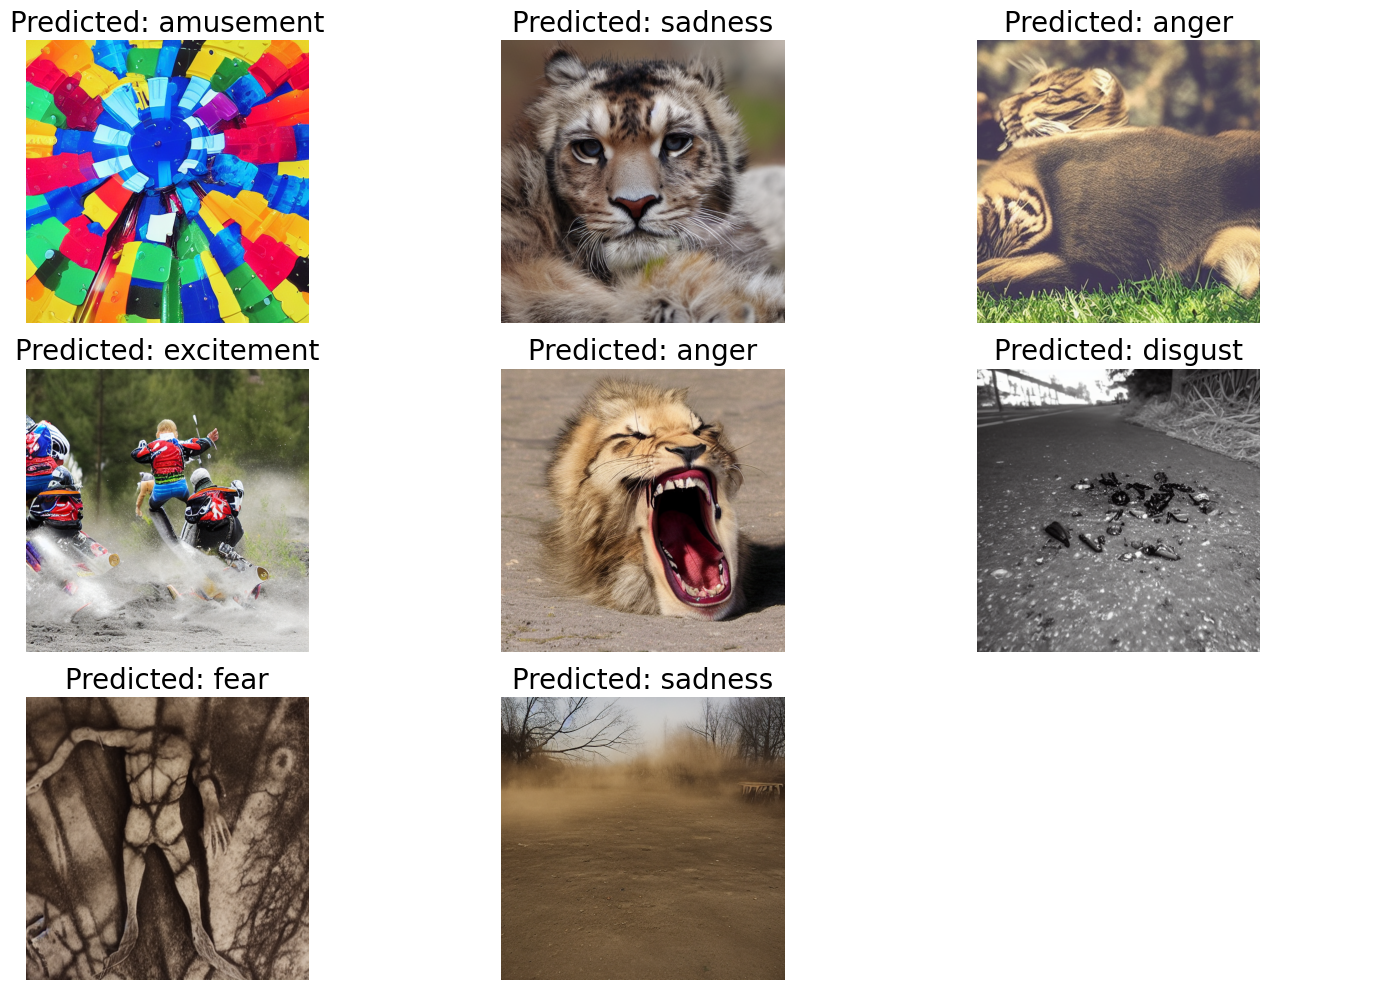

In [4]:
# Image folder path
image_folder = r'./output'  #test images are in EmotionCLIP repo : jiangchengchengNLP/EmotionCLIP
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith('emoset.png')]

# Emotion label mapping
consist_json = {
    'amusement': 0,
    'anger': 1,
    'awe': 2,
    'contentment': 3,
    'disgust': 4,
    'excitement': 5,
    'fear': 6,
    'sadness': 7,
    'neutral': 8
}
reversal_json = {v: k for k, v in consist_json.items()}
text_list = [f"This picture conveys a sense of {key}" for key in consist_json.keys()]
text_input = tokenizer(text_list)

# Create subplots
num_images = len(image_files)
rows = 3  # 3 rows
cols = 3  # 3 columns
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))  # Adjust the canvas size
axes = axes.flatten()  # Flatten the subplots to a 1D array
title_fontsize = 20

# Iterate through each image
for idx, img_path in enumerate(image_files):
    # Load image
    img = Image.open(img_path)
    img_input = preprocess(img)

    # Predict emotion
    with torch.no_grad():
        logits_per_image, _ = model(img_input.unsqueeze(0).to(device=model.device, dtype=model.dtype), text_input.to(device=model.device))
    softmax_logits_per_image = F.softmax(logits_per_image, dim=-1)
    top_k_values, top_k_indexes = torch.topk(softmax_logits_per_image, k=1, dim=-1)
    predicted_emotion = reversal_json[top_k_indexes.item()]

    # Display image and prediction result
    ax = axes[idx]
    ax.imshow(img)
    ax.set_title(f"Predicted: {predicted_emotion}", fontsize=title_fontsize)
    ax.axis('off')

# Hide any extra subplots
for idx in range(num_images, rows * cols):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [5]:
logits_per_image

tensor([[-20.2188,  -4.6172,   2.7168,   1.7852,  -5.7969,  -4.5625,   8.0156,
           8.4531, -10.2891]], device='cuda:0', dtype=torch.float16)

In [6]:
text_list

['This picture conveys a sense of amusement',
 'This picture conveys a sense of anger',
 'This picture conveys a sense of awe',
 'This picture conveys a sense of contentment',
 'This picture conveys a sense of disgust',
 'This picture conveys a sense of excitement',
 'This picture conveys a sense of fear',
 'This picture conveys a sense of sadness',
 'This picture conveys a sense of neutral']